# CASO PRÁCTICO 5

### Nombre:
            José Manuel Rábago Fernández

## 1. Importación de Librerías

In [1]:
# Librerías a importar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import cross_val_score, train_test_split, RandomizedSearchCV
from sklearn import ensemble
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

%matplotlib inline

## 2. Carga de Datasets

In [2]:
# Cargando el dataset de entrenamiento
diamonds_data = pd.read_csv('../Caso Practico 5/diamonds_train.csv')

# Cargandono el dataset de prueba
diamonds_predict = pd.read_csv('../Caso Practico 5/diamonds_test.csv')

In [3]:
# Visualizar las primeras 5 filas para darnos una idea de los datos
diamonds_data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,1.21,Premium,J,VS2,62.4,58.0,4268,6.83,6.79,4.25
1,0.32,Very Good,H,VS2,63.0,57.0,505,4.35,4.38,2.75
2,0.71,Fair,G,VS1,65.5,55.0,2686,5.62,5.53,3.65
3,0.41,Good,D,SI1,63.8,56.0,738,4.68,4.72,3.00
4,1.02,Ideal,G,SI1,60.5,59.0,4882,6.55,6.51,3.95


## 3. Análisis Exploratorio de  Datos

In [4]:
# Información general de las columnas del dataset
diamonds_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40455 entries, 0 to 40454
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    40455 non-null  float64
 1   cut      40455 non-null  object 
 2   color    40455 non-null  object 
 3   clarity  40455 non-null  object 
 4   depth    40455 non-null  float64
 5   table    40455 non-null  float64
 6   price    40455 non-null  int64  
 7   x        40455 non-null  float64
 8   y        40455 non-null  float64
 9   z        40455 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.1+ MB


In [5]:
# Describimos los valores numéricos
diamonds_data.describe()

,carat,depth,table,price,x,y,z
count,40455.000000,40455.000000,40455.000000,40455.000000,40455.000000,40455.000000,40455.000000
mean,0.797706,61.752841,57.446133,3928.444469,5.729392,5.732819,3.537154
std,0.475544,1.431725,2.233535,3992.416147,1.124453,1.146650,0.697062
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,945.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2397.000000,5.690000,5.710000,3.520000
75%,1.040000,62.500000,59.000000,5331.000000,6.540000,6.540000,4.035000
max,4.500000,79.000000,95.000000,18823.000000,10.230000,58.900000,8.060000


In [6]:
# Valores únicos de la variable categoríca 'cut'
diamonds_data['cut'].unique()

array(['Premium', 'Very Good', 'Fair', 'Good', 'Ideal'], dtype=object)

In [7]:
# Valores únicos de la variable categoríca 'color'
diamonds_data['color'].unique()

array(['J', 'H', 'G', 'D', 'F', 'E', 'I'], dtype=object)

In [8]:
# Valores únicos de la variable categoríca 'clarity'
diamonds_data['clarity'].unique()

array(['VS2', 'VS1', 'SI1', 'SI2', 'IF', 'VVS1', 'VVS2', 'I1'],
      dtype=object)

### 3.1. Correlación entre variables numéricas

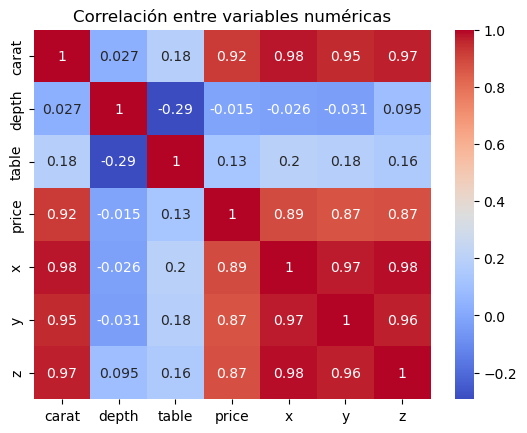

In [9]:
# Separación de las variables numéricas del dataset
numeric = diamonds_data.select_dtypes(include='number')

# Correlación entre las variables numéricas
corr = numeric.corr()

# Se inicializa una gráfica
plt.figure()

# Gráficalas tipo heatmap para representar la correlación de las variables numéricas
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas') # Se pone nombre a la gráfica

# Se muestra la gráfica
plt.show()

### 3.2. Análisis de la variable a predecir

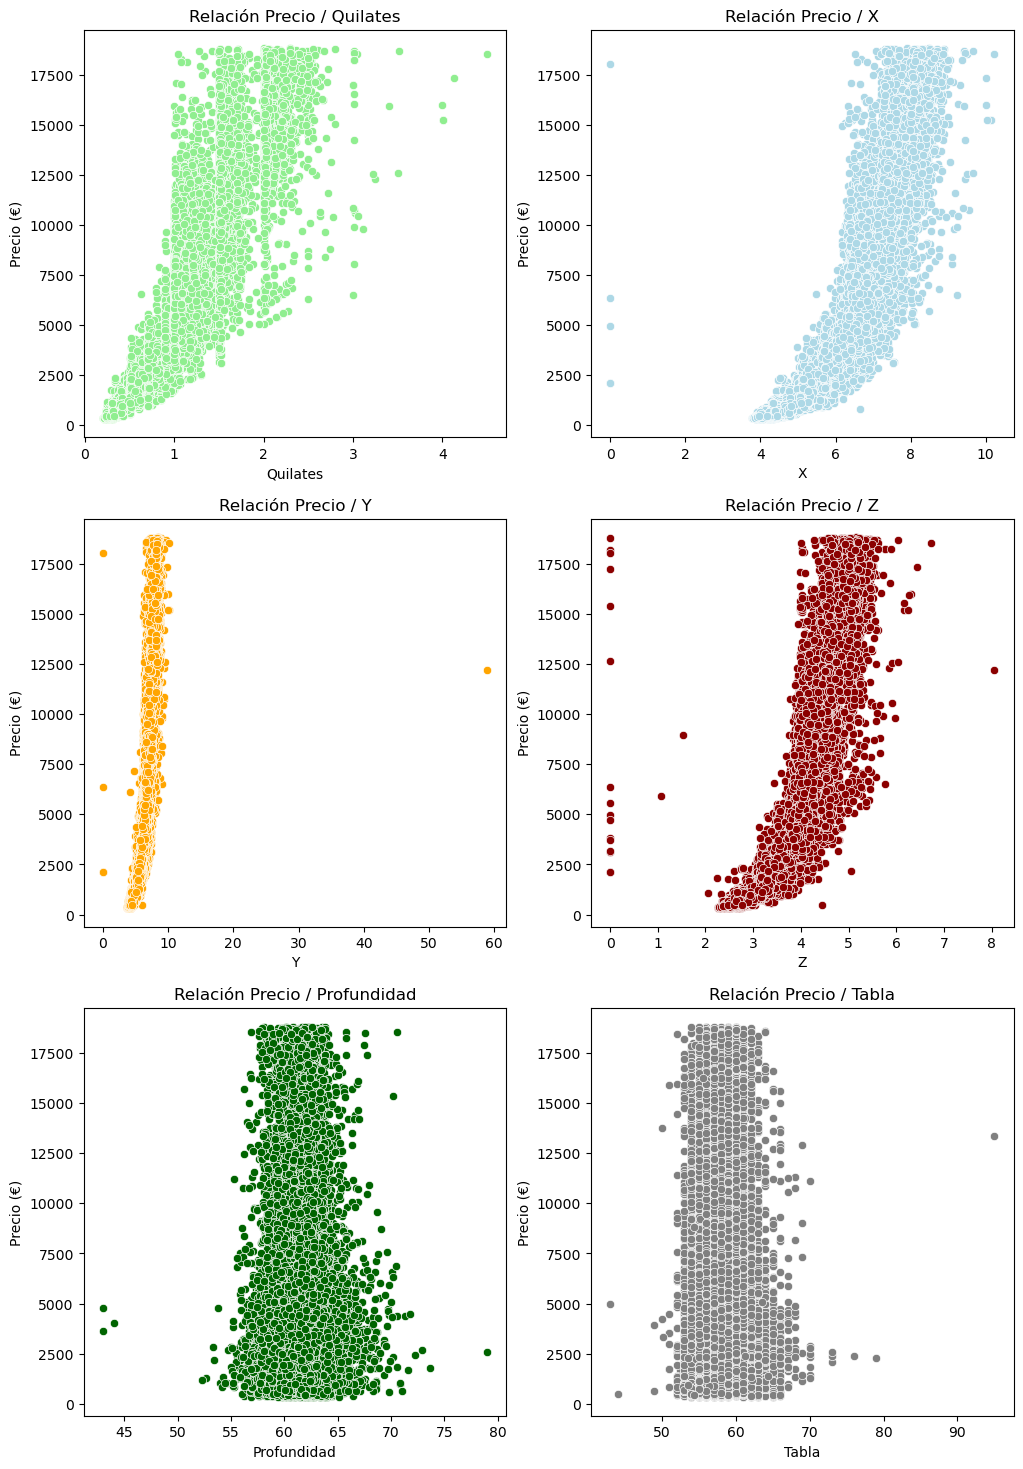

In [10]:
# Se inicializan las gráficas a realizar
fig, ax = plt.subplots(3, 2, figsize=(12, 18))

# Gráfica de relaciones entre el precio y los quilates
sns.scatterplot(data=diamonds_data, x='carat', y='price', color='lightgreen', ax=ax[0][0])
ax[0][0].set_title('Relación Precio / Quilates')
ax[0][0].set_xlabel('Quilates')
ax[0][0].set_ylabel('Precio (€)')

# Gráfica de relaciones entre el precio y x
sns.scatterplot(data=diamonds_data, x='x', y='price', color='lightblue', ax=ax[0][1])
ax[0][1].set_title('Relación Precio / X')
ax[0][1].set_xlabel('X')
ax[0][1].set_ylabel('Precio (€)')

# Gráfica de relaciones entre el precio y y
sns.scatterplot(data=diamonds_data, x='y', y='price', color='orange', ax=ax[1][0])
ax[1][0].set_title('Relación Precio / Y')
ax[1][0].set_xlabel('Y')
ax[1][0].set_ylabel('Precio (€)')

# Gráfica de relaciones entre el precio y z
sns.scatterplot(data=diamonds_data, x='z', y='price', color='darkred', ax=ax[1][1])
ax[1][1].set_title('Relación Precio / Z')
ax[1][1].set_xlabel('Z')
ax[1][1].set_ylabel('Precio (€)')

# Gráfica de relaciones entre el precio y la profundidad
sns.scatterplot(data=diamonds_data, x='depth', y='price', color='darkgreen', ax=ax[2][0])
ax[2][0].set_title('Relación Precio / Profundidad')
ax[2][0].set_xlabel('Profundidad')
ax[2][0].set_ylabel('Precio (€)')

# Gráfica de relaciones entre el precio y la tabla
sns.scatterplot(data=diamonds_data, x='table', y='price', color='grey', ax=ax[2][1])
ax[2][1].set_title('Relación Precio / Tabla')
ax[2][1].set_xlabel('Tabla')
ax[2][1].set_ylabel('Precio (€)')

# Se muestran las gráficas
plt.show()

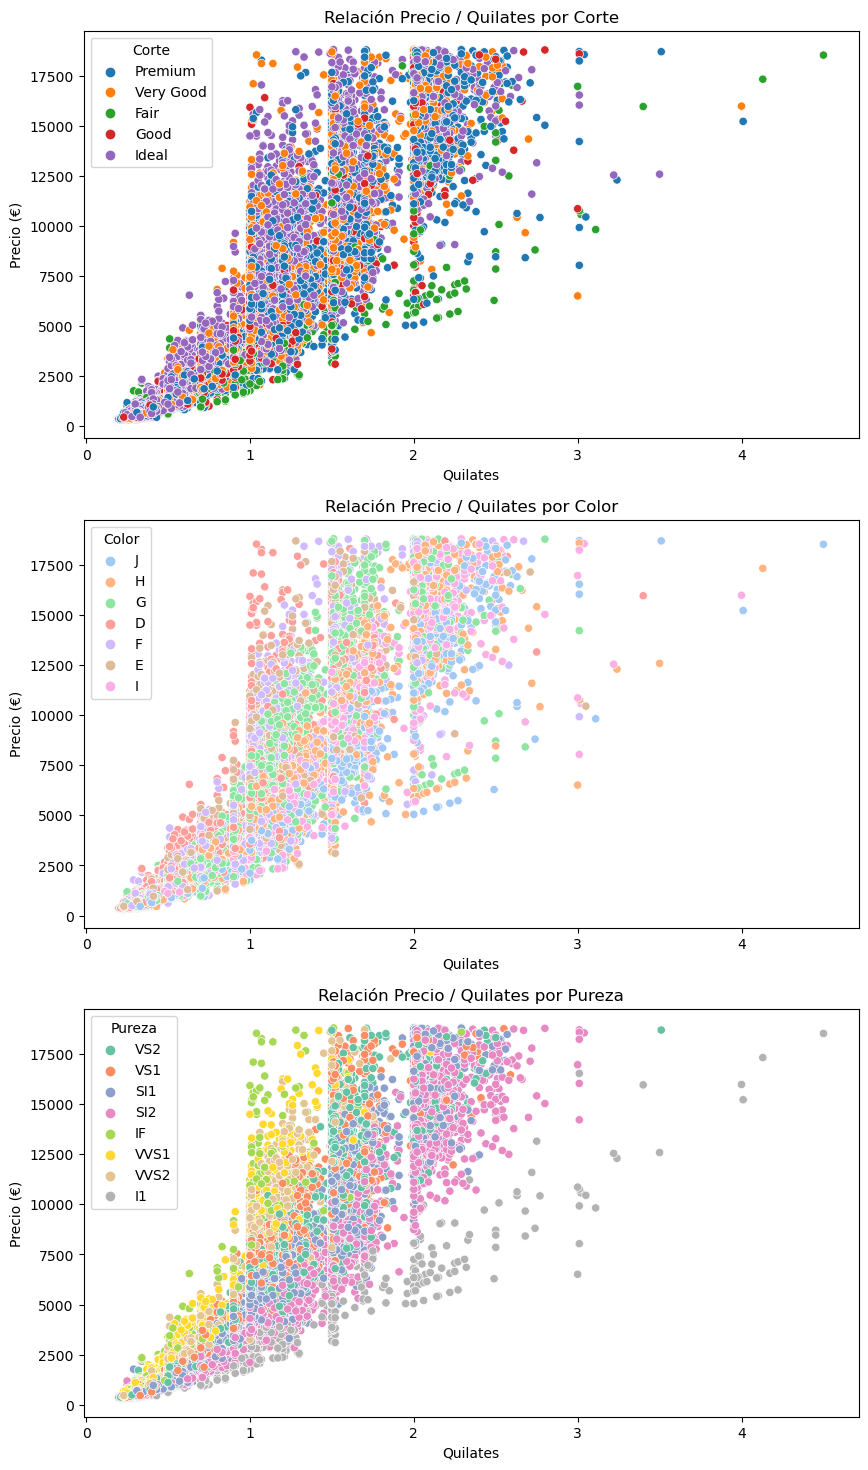

In [11]:
# Se inicializan las gráficas a realizar
fig, ax = plt.subplots(3, 1, figsize=(10, 18))

# Gráfica del Precio / Quilates con la hue por corte
sns.scatterplot(data=diamonds_data, x='carat', y='price', hue='cut', ax=ax[0])
ax[0].set_title('Relación Precio / Quilates por Corte')
ax[0].set_xlabel('Quilates')
ax[0].set_ylabel('Precio (€)')
ax[0].legend(title='Corte')

# Gráfica del Precio / Quilates con la hue por color
sns.scatterplot(data=diamonds_data, x='carat', y='price', hue='color', palette='pastel', ax=ax[1])
ax[1].set_title('Relación Precio / Quilates por Color')
ax[1].set_xlabel('Quilates')
ax[1].set_ylabel('Precio (€)')
ax[1].legend(title='Color')

# Gráfica del Precio / Quilates con la hue por pureza
sns.scatterplot(data=diamonds_data, x='carat', y='price', hue='clarity', palette='Set2', ax=ax[2])
ax[2].set_title('Relación Precio / Quilates por Pureza')
ax[2].set_xlabel('Quilates')
ax[2].set_ylabel('Precio (€)')
ax[2].legend(title='Pureza')

# Se muestran las gráficas
plt.show()

<Figure size 640x480 with 0 Axes>

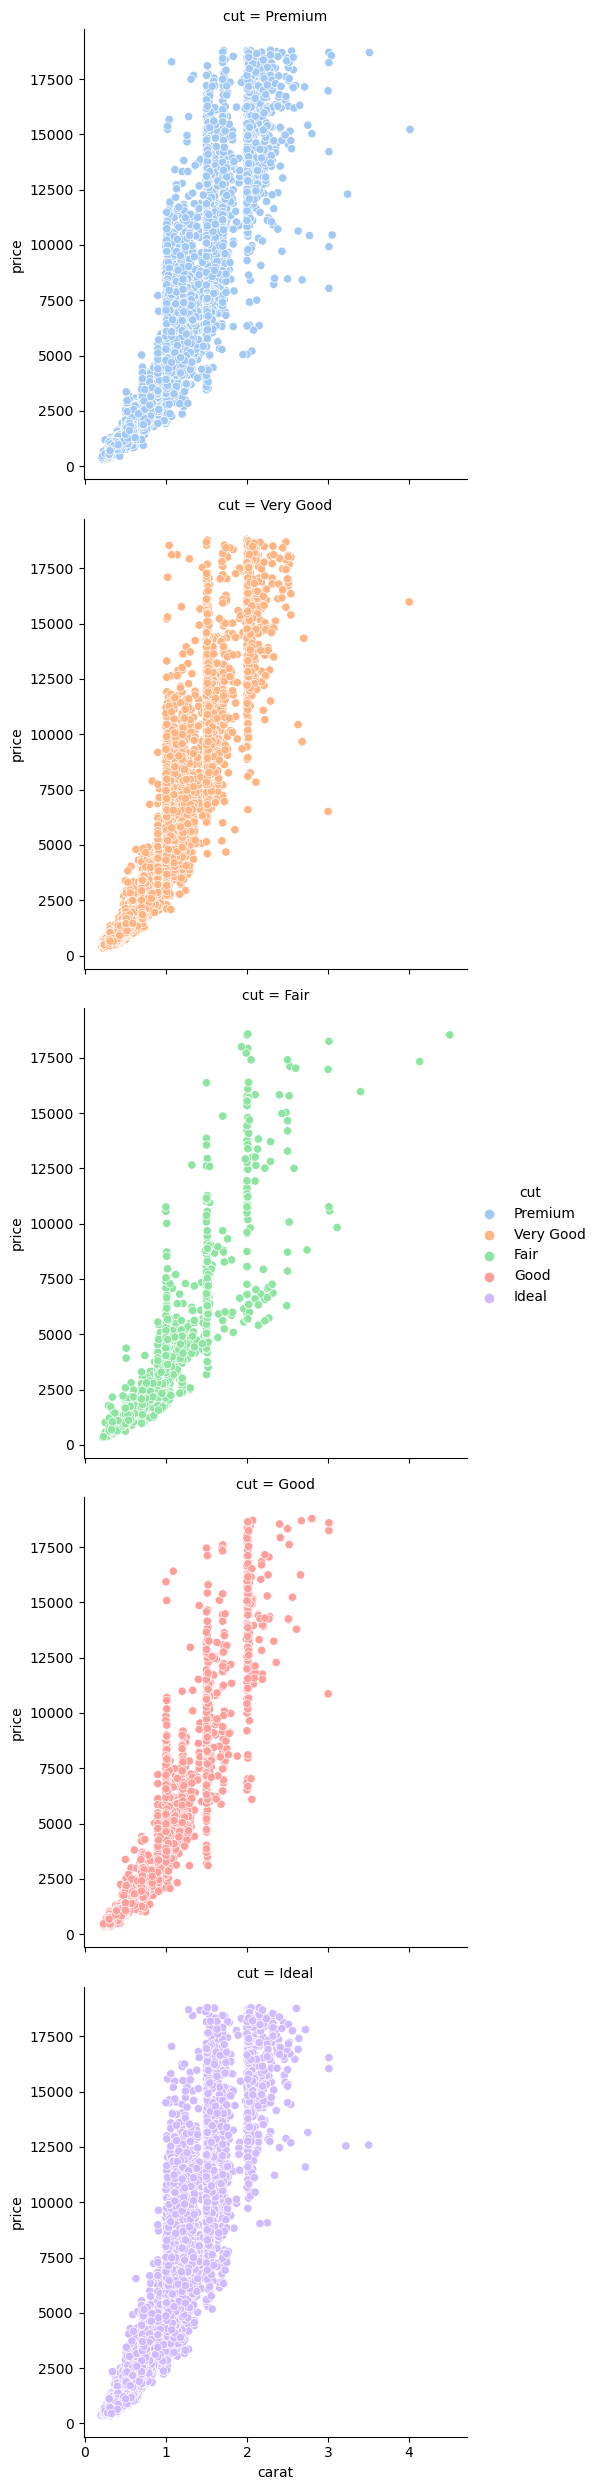

In [12]:
plt.figure()
ax = sns.relplot(x="carat", y="price", hue='cut', col="cut", data=diamonds_data, palette='pastel', col_wrap=1)
plt.show()

## 4. Modelado de Datos

In [13]:
# Pasamos las variables categorícas a variables numéricas del data set con el que se entrena
dummies = pd.get_dummies(diamonds_data.loc[:, ['cut', 'color', 'clarity']])

# Unimos el dataframe original con el dataframe de los dummies de las variables categóricas
diamonds_train = pd.concat([diamonds_data.drop(diamonds_data.loc[:, ['cut', 'color', 'clarity']], axis=1), dummies], axis=1)

# Visualizamos el nuevo dataframe
diamonds_train.head()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,1.21,62.4,58.0,4268,6.83,6.79,4.25,0,0,0,...,0,1,0,0,0,0,0,1,0,0
1,0.32,63.0,57.0,505,4.35,4.38,2.75,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.71,65.5,55.0,2686,5.62,5.53,3.65,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.41,63.8,56.0,738,4.68,4.72,3.00,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,1.02,60.5,59.0,4882,6.55,6.51,3.95,0,0,1,...,0,0,0,0,1,0,0,0,0,0


In [14]:
# Realizamos la separacion del nombre de las columnas a utilizar con la objetivo
features = list(dummies.columns) + ['carat', 'depth', 'table', 'x', 'y', 'z']
target = 'price'

In [15]:
# Inicializamos el objeto scaler
scaler = StandardScaler()

# Elegimos el modelo a utilizar
model = ensemble.RandomForestRegressor(n_estimators=500,max_features="auto",max_depth=35,n_jobs=-1)

In [16]:
# Separamos el dataframe entre las variables con las que vamos a entrenar y la variable objetivo
x = scaler.fit_transform(diamonds_train.loc[:,features].values)
y = diamonds_data[target]

In [17]:
# Separamos el dataframe en 2: con el que vamos a entrenar y con el que vamos a realizar una prueba
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Se realiza el primer entrenamiento del modelo
model.fit(x_train, y_train)

# Se realiza la prediccion con el dataframe de prueba
y_pred = model.predict(x_test)

## 5. Chequeo de las Métricas del modelo

In [47]:
# Chequeo por r2_score
print("R2_score: ",r2_score(y_test, y_pred))

# Chequeo por la media del error cuadratico
rmse = mean_squared_error(y_pred=y_pred, y_true=y_test, squared=False)
print(f'RMSE del modelo: {rmse:.2f}')

R2_score:  0.980960883365115
RMSE del modelo: 556.82


In [31]:
# Chequeo de la métrica utilizandoselo cross_val_score
scores = cross_val_score(model, x, y, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
np.mean(-scores)

558.0612139250259

## 6. Optimización del modelo

In [ ]:
# Se realiza un diccionario de parámetros para buscar el mejor resultado
params = {
    'n_estimators': [16, 32, 64, 128, 256, 512],
    'max_depth': [2, 4, 8, 16, 32], 
}

# Iniciálizamos la búsqueda de los mejores parámetros para el modelo, simulando todas las posibilidades
grid_search = RandomizedSearchCV(model, params, cv=5, verbose=10, scoring='neg_root_mean_squared_error', n_jobs=-1,n_iter=32)

## 7. Entrenamiento del total de los datos

In [46]:
# Se realiza el fit con los parámetros a todos los datos para buscar los mejores
search = grid_search.fit(x, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/envs/jupyter_env/lib/python3.7/site-packages/sklearn/model_selection/_search.py:296: UserWarning: The total space of parameters 30 is smaller than n_iter=32. Running 30 iterations. For exhaustive searches, use GridSearchCV.
  UserWarning,


KeyboardInterrupt: 

In [36]:
# Imprimimos cuales son los mejores parátros que se simularon para el modelo
print(search.best_params_)

# Imprimimos el mejor score que se encontro con los parámetros
print(grid_search.best_score_)

{'n_estimators': 512, 'max_depth': 16}
-557.543577164763


## 7. Predicción para entregar

In [37]:
# Pasamos las variables categorícas a variables numéricas del dataset a predecir
dummies = pd.get_dummies(diamonds_predict.loc[:, ['cut', 'color', 'clarity']])

# Unimos el dataframe original con el dataframe de los dummies de las variables categóricas
diamonds_test = pd.concat([diamonds_predict.drop(diamonds_data.loc[:, ['cut', 'color', 'clarity']], axis=1), dummies], axis=1)

# Visualización del data set a predecir
diamonds_test.head()

,id,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0,0.79,62.7,60.0,5.82,5.89,3.67,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1.20,61.0,57.0,6.81,6.89,4.18,0,0,1,...,0,1,0,0,0,0,1,0,0,0
2,2,1.57,62.2,61.0,7.38,7.32,4.57,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,3,0.90,63.8,54.0,6.09,6.13,3.90,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,4,0.50,62.9,58.0,5.05,5.09,3.19,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [39]:
# Realizamos un fit de todos los datos ya numéricos del dataframe a predecir
X_test = scaler.transform(diamonds_test.loc[:,features].values)

In [40]:
# Realizamos la prediccion con los mejores parámetros encontrados
y_hat = grid_search.predict(X_test).clip(0, 30000)

In [41]:
# Realizamos un dataframe separado con el precio y 
submission = pd.DataFrame({'id': diamonds_predict['id'], 'price': y_hat})

In [42]:
# Pasamos el dataframe de los resultados a un archivo .csv
submission.to_csv('Caso_Practico_5_JoseManuelRabago.csv', index=False)

In [43]:
sub = pd.read_csv('../Caso Practico 5/Caso_Practico_5_JoseManuelRabago.csv')

In [44]:
sub.head()

,id,price
0,0,2968.534626
1,1,5400.379798
2,2,9148.970701
3,3,4141.026628
4,4,1700.123332


[CV 4/5; 28/30] START max_depth=32, n_estimators=128............................
[CV 4/5; 28/30] END max_depth=32, n_estimators=128;, score=-599.301 total time=  24.5s
[CV 5/5; 29/30] START max_depth=32, n_estimators=256............................
[CV 5/5; 29/30] END max_depth=32, n_estimators=256;, score=-536.317 total time=  49.7s
[CV 1/5; 30/30] START max_depth=32, n_estimators=512............................
[CV 1/5; 30/30] END max_depth=32, n_estimators=512;, score=-548.132 total time= 1.5min
[CV 5/5; 28/30] START max_depth=32, n_estimators=128............................
[CV 5/5; 28/30] END max_depth=32, n_estimators=128;, score=-537.907 total time=  25.1s
[CV 3/5; 30/30] START max_depth=32, n_estimators=512............................
[CV 3/5; 30/30] END max_depth=32, n_estimators=512;, score=-556.931 total time= 1.5min
[CV 2/5; 30/30] START max_depth=32, n_estimators=512............................
[CV 2/5; 30/30] END max_depth=32, n_estimators=512;, score=-548.540 total time=